The purpose of this notebook is to generate plots for the OH forced-methane figure we will use as figure 3.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr
import numpy as np
from pathlib import Path
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)
from methane_noise_forcing.core import FirnFilter
from methane_noise_forcing import io, detrend_obs
from methane_noise_forcing.noise import solve_ch4_anomaly_lifetime

plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["two_column_small"]  # inches
ax_height = 1.5  # inches

# load observations

In [3]:
## parameters
site_name = "wdc06a"  # wdc05a, wdc06a, gisp2, neem
time_min = 800
time_max = 1800

## import data
with initialize(version_base=None, config_path="../../configs"):
    cfg = compose(config_name="config", overrides=["+firn_kernel=firn_model_wais"])
data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
# detrend data
data_obs_detrended = detrend_obs(site_name, data_obs)

# convert to dataset with 'ch4' and 'ch4_detrended'
data_obs = xr.Dataset(
    {
        "ch4": (["time"], data_obs.ch4),
        "ch4_detrended": (["time"], data_obs_detrended.ch4),
    },
    coords={"time": data_obs.gas_age},
)

# invert time axis
data_obs = data_obs.isel(time=slice(None, None, -1))

2025-09-26 16:39:19,838 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-09-26 16:39:19,845 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


# generate OH-forced noise

In [4]:
# read in OH forcing data
ds = xr.open_dataset(Path(cfg.paths.data_dir) / "oh_forcing" / "oh_forcing.nc")
# extract OH
da_oh_mean = ds["OH"].mean(dim="time")
da_oh_anomaly = ds["OH"] - da_oh_mean
da_oh_anomaly_fraction = da_oh_anomaly / da_oh_mean

# choose appropriate selection
column = "free_trop"
region = "tropical"

oh_mean = da_oh_mean.sel(region=region, column=column).values.item()
oh_anomaly = da_oh_anomaly.sel(region=region, column=column)
oh_anomaly_fraction = da_oh_anomaly_fraction.sel(region=region, column=column)

In [5]:
# choose ch4 mean (for rate constant) and mean lifetime
lifetime_mean = 10 # years
ch4_mean = 650 # ppb
# calculated values
rate_mean = ch4_mean / lifetime_mean  # ppb/year
S_anomaly = -rate_mean * oh_anomaly_fraction  # ppb/year
t_eval = np.arange(3001, 6002, 1) # years

result_anomaly = solve_ch4_anomaly_lifetime(
    t_eval=t_eval,
    C0_anom=0,
    S_anom=(S_anomaly.time.values, S_anomaly.values * 1e-9),
    tau=lifetime_mean,
    max_step=0.1, # year
)

In [6]:
# smooth the result with a firn smoothing kernel
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)

result_anomaly_smoothed = firn_filter.apply(
    result_anomaly.C,
    dt_series=np.mean(np.diff(t_eval))
)

In [7]:
# make dataset for plotting
oh_forced_ch4 = xr.Dataset(
    {
        "ch4": (["time"], result_anomaly.C),
        "ch4_smoothed": (["time"], result_anomaly_smoothed),
    },
    coords={"time": result_anomaly.t},
)

# Assembling full plot

In [8]:
## functions
def format_xticks(ax, direction="in", length_major=4, length_minor=2, show_label=False):
    if not show_label:
        ax.set_xticklabels([])  # 1. no labels
    ax.tick_params(
        axis="x", which="major", direction=direction, length=length_major
    )  # 2. major ticks inside
    ax.xaxis.set_minor_locator(
        plt.MultipleLocator((ax.get_xticks()[1] - ax.get_xticks()[0]) / 2)
    )  # 3. minor ticks halfway
    ax.tick_params(
        axis="x", which="minor", direction=direction, length=length_minor
    )  # minor ticks inside, shorter

def annotate_panel(ax, text, loc="left", dy=0, pad=0.01, color='k', **kwargs):
    """Place bold text at the top-left/right inside an axis."""
    x = pad if loc == "left" else 1 - pad
    ha = "left" if loc == "left" else "right"
    ax.text(
        x,
        0.98 + dy,
        text,
        transform=ax.transAxes,
        ha=ha,
        va="top",
        fontweight="bold",
        color=color,
        **kwargs
    )

def year_label(timescale: float) -> str:
    """Singular/plural label."""
    return "year" if abs(timescale - 1) < 1e-12 else "years"


def timescale_label(letter: str, tau: float) -> str:
    """
    Build '(c) \\boldsymbol{\\tau}_{\\varepsilon} = 10 years'
    (entire string will be bold via annotate_panel; math part bolded via \\boldsymbol)
    """
    return (
        f"({letter}) "
        + r"$\boldsymbol{\tau}_{\varepsilon}$"
        + f" = {tau:g} {year_label(tau)}"
    )

def _sigma_text(val: float) -> str:
    return f"\u03C3\u00A0=\u00A0{val:.1f}"

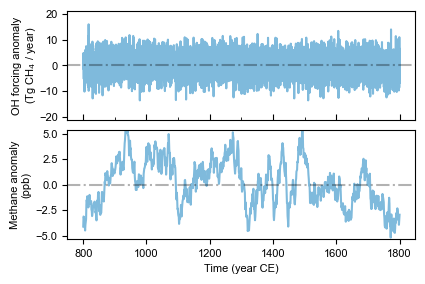

In [9]:
# parameters
ppb_to_Tg = 2.75 # multiplicative conversion from ppb to Tg ch4
oh_fraction_to_Tg_yr = -rate_mean * ppb_to_Tg # multiplicative conversion from fraction anomaly to forcing (Tg ch4/yr)
oh_scaling = 1 # scaling factor for OH-forced methane
instantaneous_offset = 35
ylim_forcing = (-21, 21) # Tg/yr
yticks_forcing = [-20, -10, 0, 10, 20] # Tg/yr
ylim_methane = (-5.3, 5.3) # ppb
yticks_methane = [-5, -2.5, 0, 2.5, 5] # ppb
timescale_plot = 1 # years
xticks = [800, 1000, 1200, 1400, 1600, 1800]
time_min_oh = 3200 # year
time_max_oh = 4200 # year
time_min_obs = 800 # year
time_max_obs = 1800 # year
plot_kwargs = {
    "obs": {
        "color": "k",
        "marker": "o",
        "linestyle": "None",
        "markersize": 2.5,
    },
    "instantaneous": {"color": colors_vibrant["blue"], "linestyle": "-", "alpha": 0.5},
    "smoothed": {
        "color": colors_vibrant["magenta"],
        "linestyle": "-",
        "linewidth": 5,
        "alpha": 0.55,
    },
}

time_slice_oh = slice(time_min_oh, time_max_oh)
time_slice_instantaneous = slice(time_min_oh + instantaneous_offset, time_max_oh + instantaneous_offset)
time_slice_obs = slice(time_min_obs, time_max_obs)

fig = plt.figure(figsize=(fig_width, 3 * ax_height))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    hspace=0.1
)

## top plot: OH forcing
ax_oh = fig.add_subplot(gs[0, 0])
# subset and transform time axis to match
oh_anomaly_plot = oh_anomaly_fraction.sel(time=slice(time_min_oh, time_max_oh))
time_oh = oh_anomaly_plot.time.values - time_min_oh + time_min_obs
ax_oh.plot(time_oh, 
           oh_anomaly_plot * oh_fraction_to_Tg_yr, 
           **plot_kwargs["instantaneous"])
ax_oh.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_oh.set_ylabel("OH forcing anomaly\n(Tg CH$_4$ / year)", labelpad=1)
ax_oh.set_ylim(ylim_forcing)
ax_oh.set_yticks(yticks_forcing)
ax_oh.set_xticks(xticks)
format_xticks(ax_oh)

## bottom plot: methane concentrations
ax_methane = fig.add_subplot(gs[1, 0])
# plot OH-driven simulation
ax_methane.plot( # instantaneous
    oh_forced_ch4.sel(time=time_slice_oh).time - time_min_oh + time_min_obs,
    oh_forced_ch4.sel(time=time_slice_oh)["ch4"] * 1e9 * oh_scaling,
    **plot_kwargs["instantaneous"]
)
# ax_methane.plot( # smoothed
#     oh_forced_ch4.sel(time=time_slice_oh).time - time_min_oh + time_min_obs,
#     oh_forced_ch4.sel(time=time_slice_instantaneous)["ch4_smoothed"] * 1e9 * oh_scaling,
#     **plot_kwargs["smoothed"]
# )
# # plot observations
# data_plot = data_obs["ch4_detrended"].sel(time=time_slice_obs)
# ax_methane.plot(data_plot.time, data_plot, **plot_kwargs["obs"])
ax_methane.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_methane.set_ylabel("Methane anomaly\n(ppb)", labelpad=3)
ax_methane.set_xlabel("Time (year CE)")
ax_methane.set_ylim(ylim_methane)
ax_methane.set_yticks(yticks_methane)

# ## annotations
# annotate_panel(ax_oh, timescale_label("a", 0.13) + ", GFDL-CM3 OH", loc="left", color='k')
# annotate_panel(ax_methane, "(b)", loc="left", color='k')

# # standard deviations
# # top panel
# annotate_panel(
#     ax_oh, 
#     _sigma_text((oh_anomaly_plot * oh_fraction_to_Tg_yr).std(ddof=1)), 
#     loc="right", 
#     color=plot_kwargs["instantaneous"]["color"],
#     alpha=0.8
# )
# # bottom panel
# dy = -0.1
# annotate_panel( # instantaneous
#     ax_methane, 
#     _sigma_text((oh_forced_ch4.sel(time=time_slice_oh)["ch4"] * 1e9).std(ddof=1) * oh_scaling), 
#     loc="right", 
#     color=plot_kwargs["instantaneous"]["color"],
#     alpha=0.8,
#     dy=0
# )
# annotate_panel( # smoothed
#     ax_methane, 
#     _sigma_text((oh_forced_ch4.sel(time=time_slice_oh)["ch4_smoothed"] * 1e9).std(ddof=1) * oh_scaling), 
#     loc="right", 
#     color=plot_kwargs["smoothed"]["color"],
#     alpha=0.8,
#     dy=dy
# )

# # legend (bottom right corner of last row)
# legend_x = 0.99
# legend_y_start = 0.01
# legend_dy = 0.1
# ax_methane.text(
#     1 - legend_x,
#     legend_y_start + legend_dy,
#     f"OH-forced atmospheric x {oh_scaling}",
#     color=plot_kwargs["instantaneous"]["color"],
#     fontweight="bold",
#     ha="left",
#     va="bottom",
#     transform=ax_methane.transAxes,
# )
# ax_methane.text(
#     1 - legend_x,
#     legend_y_start,
#     "WAIS, Mitchell et al. (2013)",
#     color=plot_kwargs["obs"]["color"],
#     fontweight="bold",
#     ha="left",
#     va="bottom",
#     transform=ax_methane.transAxes,
# )

# # save figure in pdf format
# name = "fig_3"
# fig.savefig(
#     f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.png", bbox_inches="tight", dpi=300
# )

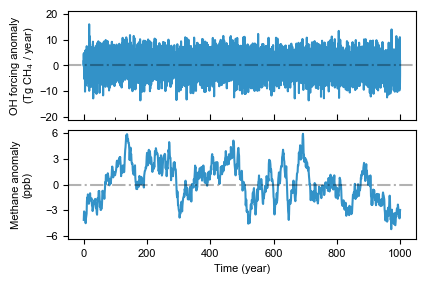

In [10]:
# parameters
ppb_to_Tg = 2.75 # multiplicative conversion from ppb to Tg ch4
oh_fraction_to_Tg_yr = -rate_mean * ppb_to_Tg # multiplicative conversion from fraction anomaly to forcing (Tg ch4/yr)
oh_scaling = 1 # scaling factor for OH-forced methane
instantaneous_offset = 35
ylim_forcing = (-21, 21) # Tg/yr
yticks_forcing = [-20, -10, 0, 10, 20] # Tg/yr
ylim_methane = (-6.3, 6.3) # ppb
yticks_methane = [-6, -3, 0, 3, 6] # ppb
timescale_plot = 1 # years
xticks = [0, 200, 400, 600, 800, 1000]
time_min_oh = 3200 # year
time_max_oh = 4200 # year
time_min_obs = 0 # year
time_max_obs = 1000 # year
plot_kwargs = {
    "obs": {
        "color": "k",
        "marker": "o",
        "linestyle": "None",
        "markersize": 2.5,
    },
    "instantaneous": {"color": colors_vibrant["blue"], "linestyle": "-", "alpha": 0.8},
    "smoothed": {
        "color": colors_vibrant["magenta"],
        "linestyle": "-",
        "linewidth": 5,
        "alpha": 0.55,
    },
}

time_slice_oh = slice(time_min_oh, time_max_oh)
time_slice_instantaneous = slice(time_min_oh + instantaneous_offset, time_max_oh + instantaneous_offset)
time_slice_obs = slice(time_min_obs, time_max_obs)

fig = plt.figure(figsize=(fig_width, 3 * ax_height))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    hspace=0.1
)

## top plot: OH forcing
ax_oh = fig.add_subplot(gs[0, 0])
# subset and transform time axis to match
oh_anomaly_plot = oh_anomaly_fraction.sel(time=slice(time_min_oh, time_max_oh))
time_oh = oh_anomaly_plot.time.values - time_min_oh
ax_oh.plot(time_oh, 
           oh_anomaly_plot * oh_fraction_to_Tg_yr, 
           **plot_kwargs["instantaneous"])
ax_oh.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_oh.set_ylabel("OH forcing anomaly\n(Tg CH$_4$ / year)", labelpad=2.5)
ax_oh.set_ylim(ylim_forcing)
ax_oh.set_yticks(yticks_forcing)
ax_oh.set_xticks(xticks)
format_xticks(ax_oh)

## middle plot: methane concentrations
ax_methane = fig.add_subplot(gs[1, 0])
# plot OH-driven simulation
ax_methane.plot( # instantaneous
    oh_forced_ch4.sel(time=time_slice_oh).time - time_min_oh,
    oh_forced_ch4.sel(time=time_slice_oh)["ch4"] * 1e9 * oh_scaling,
    **plot_kwargs["instantaneous"]
)
# ax_methane.plot( # smoothed
#     oh_forced_ch4.sel(time=time_slice_oh).time - time_min_oh + time_min_obs,
#     oh_forced_ch4.sel(time=time_slice_instantaneous)["ch4_smoothed"] * 1e9 * oh_scaling,
#     **plot_kwargs["smoothed"]
# )

ax_methane.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_methane.set_ylabel("Methane anomaly\n(ppb)", labelpad=9.2)
ax_methane.set_xlabel("Time (year)")
ax_methane.set_ylim(ylim_methane)
ax_methane.set_yticks(yticks_methane)

# save figure in pdf format
name = "fig_3"
fig.savefig(
    f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.png", bbox_inches="tight", dpi=300
)

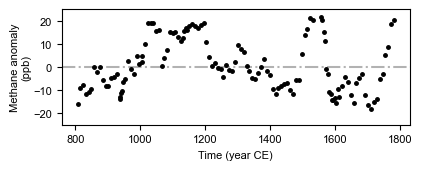

In [11]:
## plot obs in separate figure
fig = plt.figure(figsize=(fig_width, 1 * ax_height))
gs = GridSpec(
    nrows=1,
    ncols=1,
    figure=fig,
    hspace=0.1
)
ylim_methane = (-25.15, 25.15) # ppb
# yticks_methane = [-6, -3, 0, 3, 6] # ppb
yticks_methane = [-20, -10, 0, 10, 20] # ppb
time_min_obs = 800 # year
time_max_obs = 1800 # year

# # plot observations
ax_methane = fig.add_subplot(gs[0, 0])
time_slice_obs = slice(time_min_obs, time_max_obs)
data_plot = data_obs["ch4_detrended"].sel(time=time_slice_obs)
ax_methane.plot(data_plot.time, data_plot, **plot_kwargs["obs"])
ax_methane.axhline(0, color="k", linestyle="-.", alpha=0.3)
ax_methane.set_ylabel("Methane anomaly\n(ppb)", labelpad=1.2)
ax_methane.set_xlabel("Time (year CE)")
ax_methane.set_ylim(ylim_methane)
ax_methane.set_yticks(yticks_methane)

# save figure in pdf format
name = "fig_3_just_obs"
fig.savefig(
    f"{cfg.paths.figures_dir}/figures_for_seminar/{name}.png", bbox_inches="tight", dpi=300
)